In [84]:
from sklearn.datasets import make_regression
import numpy as np

In [85]:
X, y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1, noise=80, random_state=13)

In [86]:
X

array([[-0.71239066],
       [ 0.45181234],
       [-0.04450308],
       [ 0.75376638]])

In [87]:
y

array([  7.21786552,  16.04609925, -27.83756166, 144.36688189])

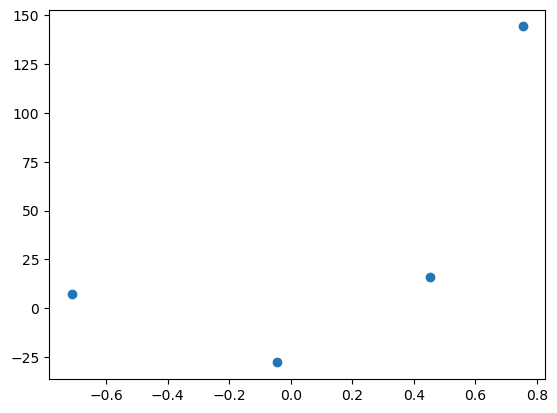

In [88]:
import matplotlib.pyplot as plt
plt.scatter(X, y)

### First Apply OLS
To get the values of m and b and compare them later with values of m and b calculated from gradient descent

In [89]:
from sklearn.linear_model import LinearRegression

In [90]:
lr = LinearRegression()

In [91]:
lr.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [92]:
lr.coef_

array([78.35063668])

In [93]:
lr.intercept_

np.float64(26.15963284313262)

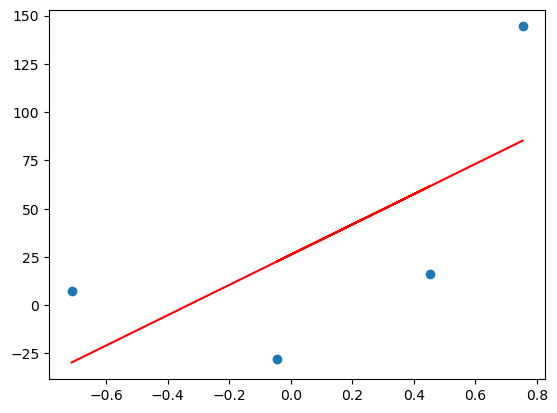

In [94]:
plt.scatter(X, y)
plt.plot(X, lr.predict(X), color='red')

### Apply Gradient Descent 
By considering slope is constant m = 78.35

and assuming the starting value for intercept b = 0

In [95]:
y_pred = ((78.35 * X) + 0).reshape(4)

In [96]:
y_pred

array([-55.81580837,  35.39949674,  -3.48681619,  59.05759577])

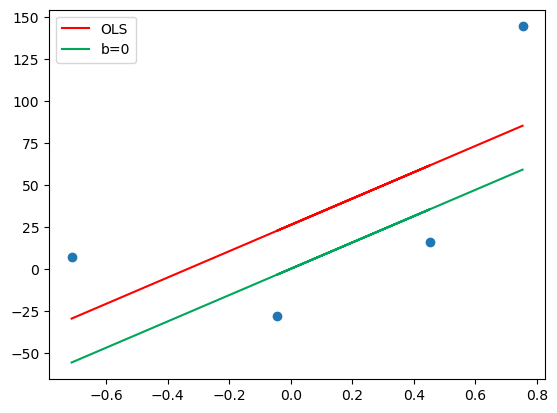

In [97]:
plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red', label='OLS')
plt.plot(X,y_pred, color='#00a65a', label='b=0')
plt.legend()
plt.show()

In [98]:
m = 78.35
b = 0

loss_slope = -2 * np.sum(y - m*X.ravel() - b)
# ravel() is a NumPy method that flattens an array into 1D.
loss_slope

np.float64(-209.27763408209216)

if X is not already 1-dimensional, X.ravel() turns it into a 1D array.

In [99]:
print(X.ravel().shape)

(4,)


### Let's take Learning Rate = 0.1

In [100]:
learning_rate = 0.1

step_size = learning_rate*loss_slope
step_size

np.float64(-20.927763408209216)

### Calculating the New Intercept

In [101]:
b = b - step_size
b

np.float64(20.927763408209216)

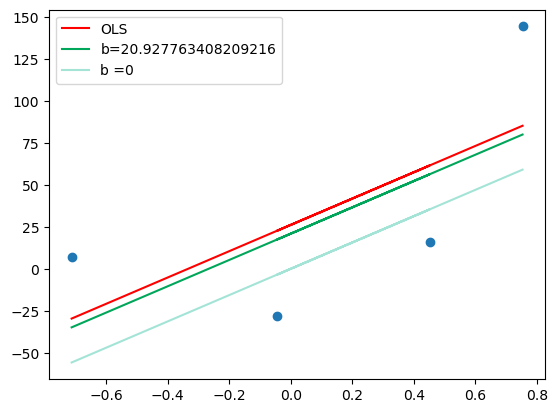

In [102]:
y_pred1 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red', label='OLS')
plt.plot(X,y_pred1, color='#00a65a', label='b={}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7', label = 'b =0')
plt.legend()
plt.show()

### Iteration 2

In [103]:
loss_slope = -2 * np.sum(y - m*X.ravel() - b)
loss_slope

np.float64(-41.85552681641845)

In [104]:
step_size = learning_rate*loss_slope
step_size

np.float64(-4.185552681641845)

In [105]:
b = b - step_size
b

np.float64(25.11331608985106)

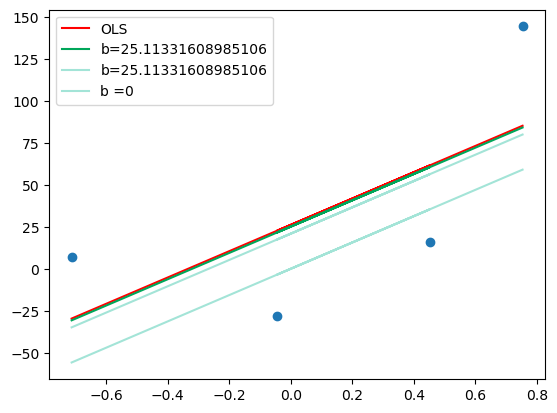

In [106]:
y_pred2 = ((78.35 * X) + b).reshape(4)

plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red', label='OLS')
plt.plot(X,y_pred2, color='#00a65a', label='b={}'.format(b))
plt.plot(X,y_pred1, color='#A3E4D7', label='b={}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7', label = 'b =0')
plt.legend()
plt.show()

### Iteration 3

In [107]:
loss_slope = -2 * np.sum(y - m*X.ravel() -b)
loss_slope

np.float64(-8.37110536328369)

In [108]:
step_size = learning_rate*loss_slope
step_size

np.float64(-0.837110536328369)

In [109]:
b = b - step_size
b

np.float64(25.95042662617943)

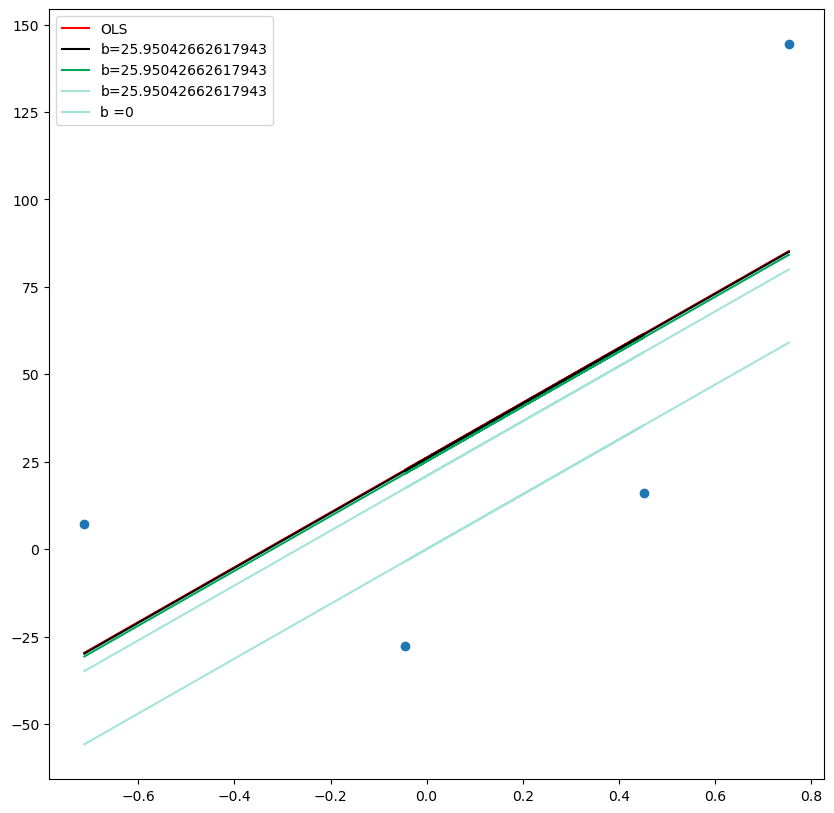

In [110]:
y_pred3 = ((78.35 * X) + b).reshape(4)

plt.figure(figsize=(10,10))
plt.scatter(X,y)
plt.plot(X, lr.predict(X), color='red', label='OLS')
plt.plot(X,y_pred3, color='black', label='b={}'.format(b))
plt.plot(X,y_pred2, color='#00a65a', label='b={}'.format(b))
plt.plot(X,y_pred1, color='#A3E4D7', label='b={}'.format(b))
plt.plot(X,y_pred,color='#A3E4D7', label = 'b =0')
plt.legend()
plt.show()

### Looping

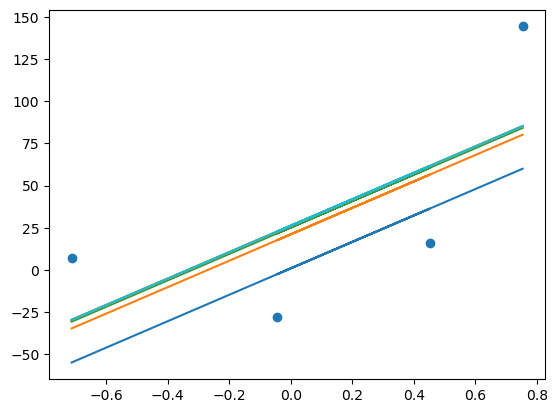

In [113]:
b = -100
m = 78.35
lr = 0.1

epochs = 10

for i in range(epochs):
    loss_slope = -2 * np.sum(y - m*X.ravel() -b)
    b = b - learning_rate*loss_slope

    y_pred = m*X + b

    plt.plot(X, y_pred)

plt.scatter(X, y)